# Task 10 

Picked smarties.png because it's genuinely awkward to segment: several objects in
different colours, sitting on a white background, with highlights and shadows on each one.
Intensity alone won't separate them properly, so it's a good test.

Three methods chosen:
1. Otsu thresholding (global, intensity based)
2. HSV colour thresholding
3. K-Means clustering with K=4

Picked these three because each one makes a different assumption about the image, so I can
see which assumption actually holds.

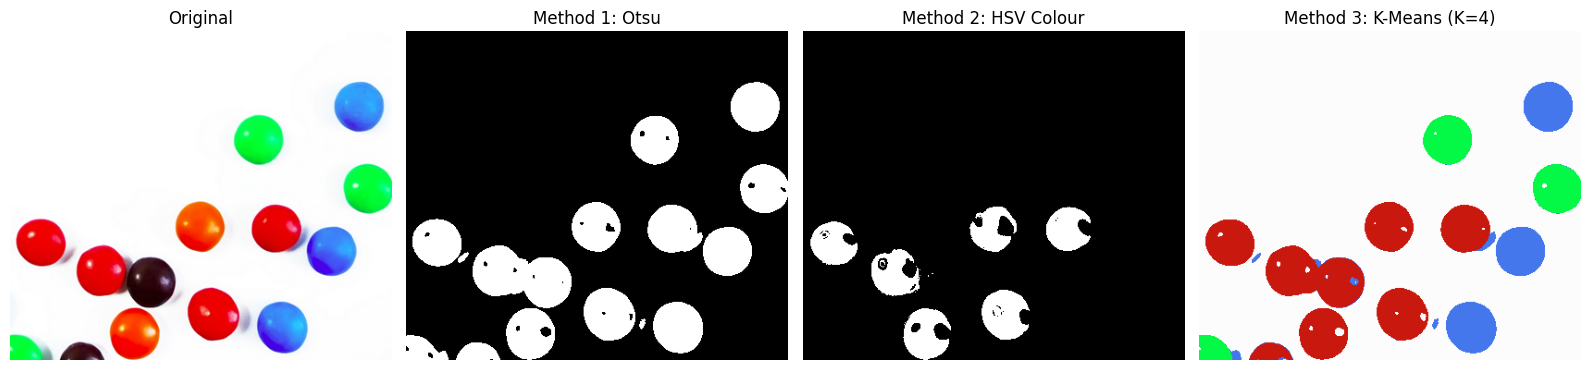

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("smarties.png")

if img is None:
    print("Error: smarties.png not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Method 1: Otsu thresholding
    _, m1 = cv2.threshold(gray, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Method 2: HSV colour thresholding (red objects)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    m2 = cv2.inRange(hsv, np.array([0, 100, 80]), np.array([10, 255, 255]))

    # Method 3: K-Means with K=4
    pixels = np.float32(img.reshape((-1, 3)))
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(pixels, 4, None, criteria, 10,
                                    cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    m3 = centers[labels.flatten()].reshape(img.shape)
    m3 = cv2.cvtColor(m3, cv2.COLOR_BGR2RGB)

    titles = ["Original", "Method 1: Otsu",
              "Method 2: HSV Colour", "Method 3: K-Means (K=4)"]
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), m1, m2, m3]

    plt.figure(figsize=(16, 4))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        if i == 1 or i == 2:
            plt.imshow(images[i], cmap="gray")
        else:
            plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Breaking down each method

**Method 1: Otsu thresholding**

* *Assumption:* the histogram has two clear humps, so objects and background can be split
  by one intensity value.
* *What it gets right:* all the objects together as one foreground against the white
  background. The outlines are clean.
* *What it gets wrong:* it can't tell the objects apart from each other. Red, green and
  blue all end up as the same white blob. It also loses the dark purple one in places since
  its brightness is closer to the shadows than to the other objects.
* *Parameter with the biggest effect:* nothing, since Otsu chooses the threshold itself.
  That's its strength and its limit at the same time.

**Method 2: HSV colour thresholding**

* *Assumption:* the object I want has a distinct hue that stays the same under different
  lighting.
* *What it gets right:* isolates exactly the red objects and ignores everything else.
  Complete solid masks.
* *What it gets wrong:* the specular highlights come out as holes, because those spots are
  nearly white so saturation drops to almost zero and they fall outside any hue range.
* *Parameter with the biggest effect:* the lower bounds on S and V. Set them too high and
  the masks come out hollow, as I saw in Task 4.

**Method 3: K-Means (K=4)**

* *Assumption:* the image can be summed up with a small number of representative colours.
* *What it gets right:* groups the objects by colour without me defining any range, and
  separates background, objects and shadow.
* *What it gets wrong:* it ignores position completely, so two objects of the same colour
  on opposite sides of the image get the same label. It also doesn't give a binary mask,
  just a simplified image.
* *Parameter with the biggest effect:* K. Too low and everything merges; too high and it
  stops simplifying anything.

### Conclusion

**HSV colour thresholding produced the most meaningful regions for this image.**

The reason is the property of the image itself: the objects differ from each other by
colour, not by brightness. Otsu only looks at intensity, so it physically cannot tell a red
object from a green one of similar brightness; the information it needs isn't in the
grayscale version. K-Means does use colour and does group things sensibly, but it gives
back a simplified image instead of a mask of one specific object, which isn't what a
sorting system needs.

HSV wins because it works in the one space where this image's objects are actually
separable, and it gives a direct binary mask of the target object.

If the objects had been the same colour but different shapes, or touching each other, this
conclusion would flip and watershed would be the better choice. The method has to match
what makes the image hard.